In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


📊 读取的数据维度: (5068, 24)
⏳ 正在使用 MICE (IterativeImputer) 算法填补特征缺失值...
✅ 缺失值填补完成！当前数据已无任何 NaN。
🎨 正在生成用于 Presentation 的统计图表...


/tmp/ipykernel_8142/163407914.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression_Status', y='Sleep_Hours', data=df_plot, palette='Set2')


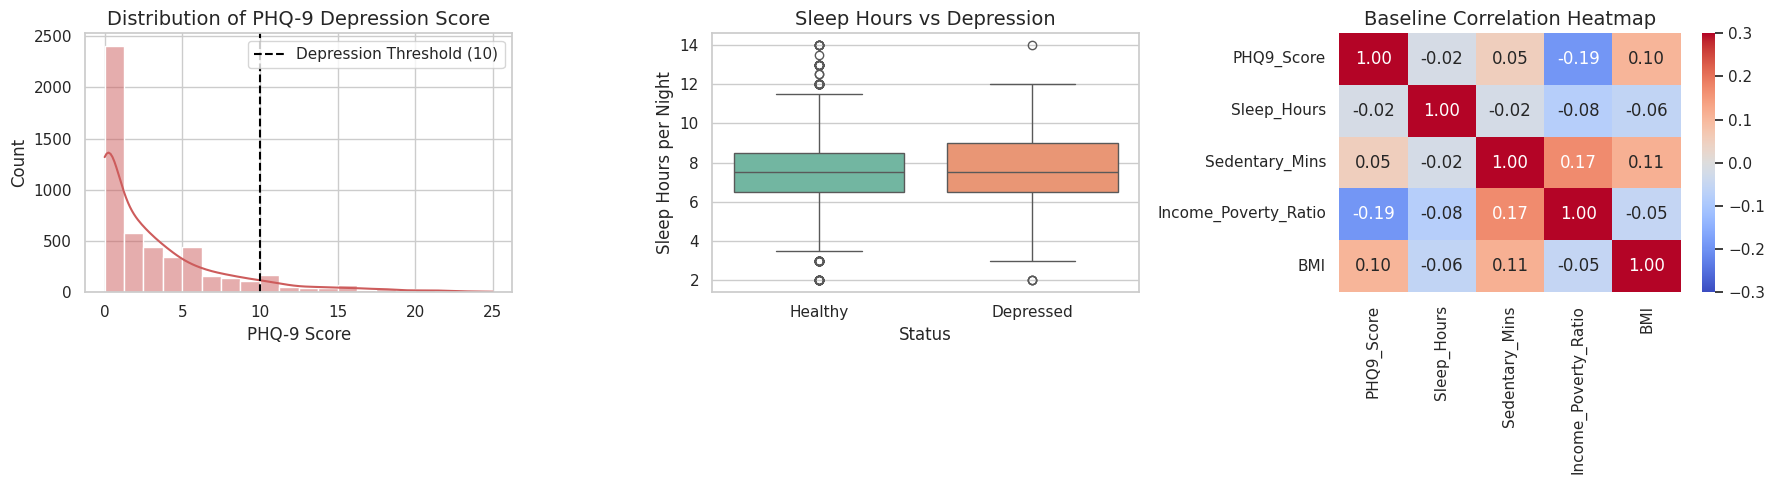

 模型用数据集保存至: /content/drive/MyDrive/Colab Notebooks/DDA4210/DataSet/NHANES_Ready_for_Causal.csv


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 启用 sklearn 的高级插补器
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. 定义数据路径并读取上一步的数据
drive_data_folder = '/content/drive/MyDrive/Colab Notebooks/DDA4210/DataSet'
file_path = os.path.join(drive_data_folder, 'NHANES_Cleaned_Step1.csv')

df = pd.read_csv(file_path)
print(f"📊 读取的数据维度: {df.shape}")

# ==========================================
# 第一步：瘦身！去掉不需要的原始问卷列
# ==========================================
# 我们已经有了总分 PHQ9_Score，所以把原始的 9 道题删掉，防止模型受到干扰
phq9_cols = [f'PHQ9_{i}' for i in range(1, 10)]
df.drop(columns=phq9_cols, inplace=True)


# ==========================================
# 第二步：使用高级机器学习方法 (MICE) 填补缺失值
# ==========================================
print("⏳ 正在使用 MICE (IterativeImputer) 算法填补特征缺失值...")

# 为了防止特征之间的量纲差异影响插补，虽然内部有线性模型，但我们直接应用即可
# 设置随机种子保证每次运行结果一致 (Reproducibility)
imputer = IterativeImputer(max_iter=10, random_state=42)

# ID列不参与插补，先单独拿出来
df_id = df['ID']
df_features = df.drop(columns=['ID'])
columns_names = df_features.columns

# 拟合并插补数据
imputed_data = imputer.fit_transform(df_features)

# 组合回 DataFrame
df_clean = pd.DataFrame(imputed_data, columns=columns_names)
df_clean.insert(0, 'ID', df_id)

# 对于一些应该是整数的分类变量，插补后可能变成小数，我们需要四舍五入恢复
int_cols = ['Gender', 'Education', 'Marital_Status', 'Cancer_History',
            'Heart_Disease_History', 'Smoking_Status']
for col in int_cols:
    df_clean[col] = df_clean[col].round()

print("✅ 缺失值填补完成！当前数据已无任何 NaN。")


# ==========================================
# 第三步：探索性数据分析 (EDA) - 画图！
# ==========================================
print("🎨 正在生成用于 Presentation 的统计图表...")

# 设置 Seaborn 绘图风格
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 图 1：抑郁症得分的分布直方图
plt.subplot(1, 3, 1)
sns.histplot(df_clean['PHQ9_Score'], bins=20, kde=True, color='indianred')
plt.axvline(x=10, color='black', linestyle='--', label='Depression Threshold (10)')
plt.title('Distribution of PHQ-9 Depression Score', fontsize=14)
plt.xlabel('PHQ-9 Score')
plt.ylabel('Count')
plt.legend()

# 图 2：睡眠时间 vs 是否抑郁 (箱线图)
plt.subplot(1, 3, 2)
# 把 Is_Depressed 映射为英文标签用于画图
df_plot = df_clean.copy()
df_plot['Depression_Status'] = df_plot['Is_Depressed'].map({0.0: 'Healthy', 1.0: 'Depressed'})

sns.boxplot(x='Depression_Status', y='Sleep_Hours', data=df_plot, palette='Set2')
plt.title('Sleep Hours vs Depression', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Sleep Hours per Night')

# 图 3：核心变量的初始相关性热力图 (Pearson Correlation)
plt.subplot(1, 3, 3)
# 选取几个核心变量看看表面的相关性
core_cols = ['PHQ9_Score', 'Sleep_Hours', 'Sedentary_Mins', 'Income_Poverty_Ratio', 'BMI']
corr_matrix = df_clean[core_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-0.3, vmax=0.3, fmt='.2f')
plt.title('Baseline Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

# ==========================================
# 保存数据集
# ==========================================
save_path_final = os.path.join(drive_data_folder, 'NHANES_Ready_for_Causal.csv')
df_clean.to_csv(save_path_final, index=False)
print(f" 模型用数据集保存至: {save_path_final}")